# 02 · Doctor density & the first map

Raw counts mislead — Tunis has 2,338 doctors, Tozeur 33, but Tunis also has 10×
the people. The honest measure is **doctors per 100,000 inhabitants**. Here we:

1. join the doctor supply to **official INS 2014 census** population,
2. reconcile it onto a **GeoJSON** of the 24 governorates, and
3. draw the first choropleth — static (`geopandas`) and interactive (`folium`).

> **Scope:** the supply is **private-practice** doctors (own cabinet) — public-
> hospital-only doctors aren't in the data. So this maps *private* doctor density,
> which tracks where private practice is viable, not total care availability.

In [1]:
import unicodedata
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

RAW = Path('..') / 'data' / 'raw'
EXT = Path('..') / 'data' / 'external'

def norm(s):
    """accent-strip + keep alphanumerics only — for matching place names."""
    s = ''.join(c for c in unicodedata.normalize('NFD', str(s).lower())
                if unicodedata.category(c) != 'Mn')
    return ''.join(ch for ch in s if ch.isalnum())

## 1 · Supply per capita

`population_governorate.csv` is generated by `src/population_tn.py` (INS RGPH
2014, keyed to our governorate slugs).

In [2]:
docs = pd.read_csv(RAW / 'doctors.csv')
pop  = pd.read_csv(EXT / 'population_governorate.csv')

supply = (docs['gouvernoratSlug'].value_counts()
            .rename_axis('gouvernoratSlug').rename('doctors').reset_index())
df = pop.merge(supply, on='gouvernoratSlug', how='left')
df['doctors'] = df['doctors'].fillna(0).astype(int)
df['per_100k'] = (df['doctors'] / df['population'] * 100_000).round(1)
df.shape

(24, 5)

### ⚠️ A join bug worth catching

First run, **Sidi Bouzid showed 0 doctors** — alarming for a 430k-person region.
It wasn't a desert, it was a **slug mismatch**: the doctor data spells it
`sidi-bouzid` (hyphen) while the population table had `sidibouzid`. Always assert
your join keys line up before trusting the numbers:

In [3]:
docs_slugs, pop_slugs = set(docs.gouvernoratSlug), set(pop.gouvernoratSlug)
assert not (pop_slugs ^ docs_slugs), f'key mismatch: {pop_slugs ^ docs_slugs}'
print('OK — all 24 governorate slugs match on both sides')

OK — all 24 governorate slugs match on both sides


National average: 89.7 doctors per 100k


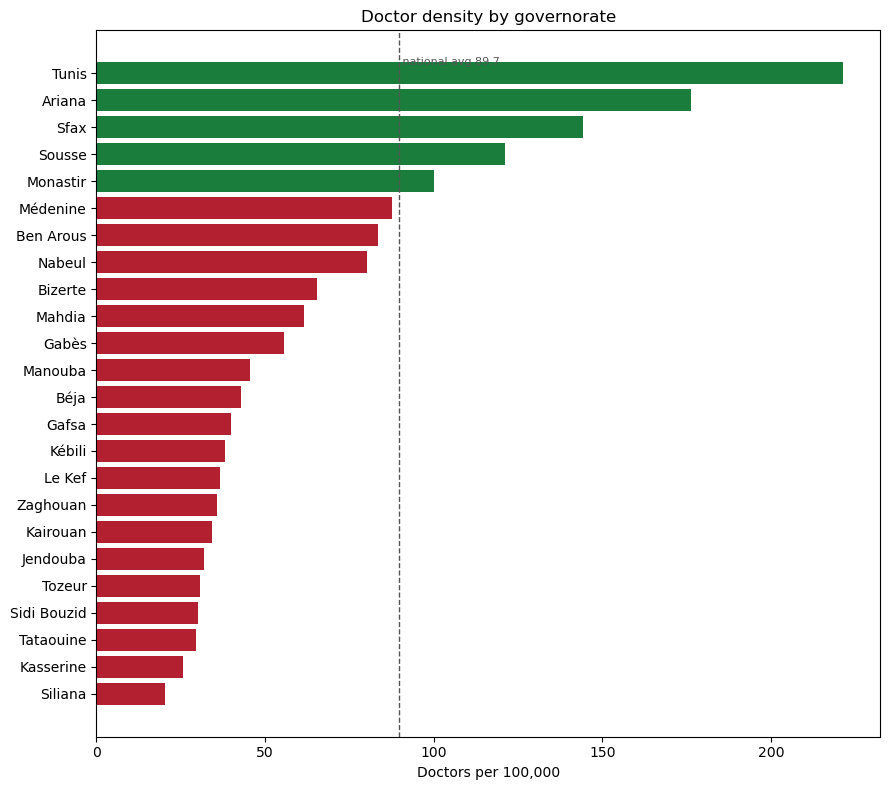

,governorate,doctors,population,per_100k
0,Tunis,2338,1056247,221.3
1,Ariana,1016,576088,176.4
17,Sfax,1380,955421,144.4
14,Sousse,819,674971,121.3
15,Monastir,550,548828,100.2
22,Médenine,420,479520,87.6
2,Ben Arous,527,631842,83.4
4,Nabeul,631,787920,80.1
6,Bizerte,372,568219,65.5
16,Mahdia,253,410812,61.6


In [4]:
national = round(df.doctors.sum() / df.population.sum() * 100_000, 1)
print(f'National average: {national} doctors per 100k')

ranked = df.sort_values('per_100k', ascending=False)
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#1a7d3c' if v >= national else '#b3202f' for v in ranked.per_100k]
ax.barh(ranked.governorate[::-1], ranked.per_100k[::-1], color=colors[::-1])
ax.axvline(national, ls='--', color='#555', lw=1)
ax.text(national, 23.3, f' national avg {national}', fontsize=8, color='#555')
ax.set_xlabel('Doctors per 100,000'); ax.set_title('Doctor density by governorate')
plt.tight_layout(); plt.show()
ranked[['governorate', 'doctors', 'population', 'per_100k']]

Red = below the national average. The pattern is stark: the **coast + capital**
(Tunis 221, Ariana 176, Sfax 144, Sousse 121) tower over the **interior & south**
(Siliana 20, Kasserine 26, Tataouine 29) — an ~11× gap.

## 2 · Reconcile onto the map (GeoJSON)

The geoBoundaries GeoJSON names governorates as `shapeName` ("Ben Arous",
"El Kef"…). We normalise those to our slugs; only `El Kef → kef` needs an
explicit override.

In [5]:
gdf = gpd.read_file(EXT / 'tunisia_governorates.geojson')
slug_by_norm = {norm(s): s for s in df['gouvernoratSlug']}
overrides = {'elkef': 'kef'}
gdf['gouvernoratSlug'] = gdf['shapeName'].map(
    lambda n: overrides.get(norm(n)) or slug_by_norm.get(norm(n)))

unmatched = gdf[gdf.gouvernoratSlug.isna()].shapeName.tolist()
assert not unmatched, f'unmatched shapes: {unmatched}'
geo = gdf.merge(df, on='gouvernoratSlug', how='left')
print('all', len(geo), 'governorate shapes matched + merged')

all 24 governorate shapes matched + merged


## 3 · The map

### Static choropleth

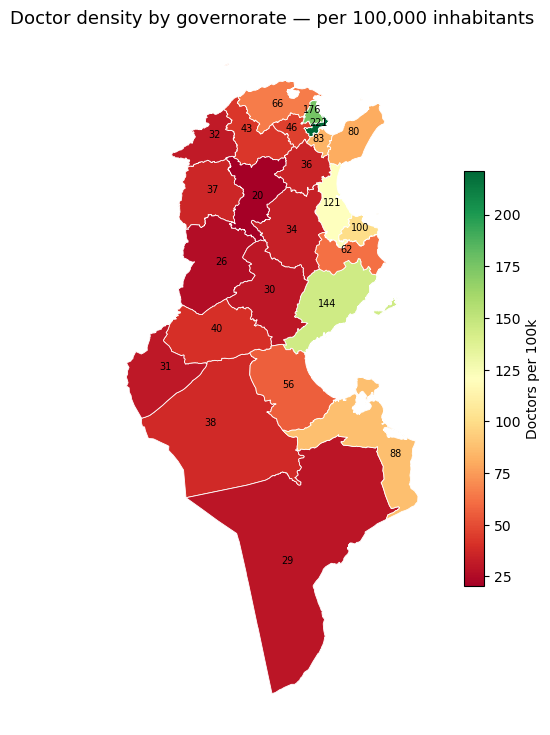

In [6]:
fig, ax = plt.subplots(figsize=(8, 9))
geo.plot(column='per_100k', cmap='RdYlGn', legend=True, edgecolor='white',
         linewidth=0.6, ax=ax,
         legend_kwds={'label': 'Doctors per 100k', 'shrink': 0.6})
ax.set_axis_off()
ax.set_title('Doctor density by governorate — per 100,000 inhabitants', fontsize=13)
# annotate each governorate with its value
for _, r in geo.iterrows():
    c = r.geometry.representative_point()
    ax.annotate(f'{r.per_100k:.0f}', (c.x, c.y), ha='center', fontsize=7)
plt.savefig('../reports/figures/density_choropleth.png', dpi=130, bbox_inches='tight')
plt.show()

### Interactive choropleth (folium)

Hover/zoom; saved to `reports/figures/density_map.html` for the portfolio.

In [7]:
import folium
m = folium.Map(location=[34, 9.5], zoom_start=6, tiles='cartodbpositron')
folium.Choropleth(
    geo_data=geo.to_json(), data=geo,
    columns=['gouvernoratSlug', 'per_100k'],
    key_on='feature.properties.gouvernoratSlug',
    fill_color='RdYlGn', fill_opacity=0.8, line_color='white',
    legend_name='Doctors per 100,000 inhabitants',
).add_to(m)
folium.GeoJson(geo.to_json(),
    tooltip=folium.GeoJsonTooltip(fields=['governorate', 'doctors', 'per_100k'],
        aliases=['Governorate', 'Doctors', 'Per 100k']),
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0}).add_to(m)
m.save('../reports/figures/density_map.html')
m

## Takeaways & next

- Tunisia's **private-practice** doctor supply is **coast-heavy**: an ~11× density
  gap from Tunis to Siliana.
- Because public-hospital doctors aren't counted, the interior gap is partly a
  *private-practice viability* gap, not a total-care gap — state this in any writeup.
- This is the *supply* desert. The **flagship** join (notebook 03) overlays GSC search
  **demand** to find where scarcity meets the most unmet search interest.

**Next:**
1. Repeat at **delegation** level (228 zones) for sharper deserts.
2. Per-specialty maps (where are the 0-cardiologist regions?).
3. A **Gini coefficient** of access as a single inequality number.
4. Overlay demand → the supply–demand gap map (the headline).